In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers":12,
    "drop_rate": 0.1,
    "qkv_bias": False
}
import torch
import torch.nn as nn

In [2]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Deep learning is so much fun"
txt2 = "It was breakthrough in LLMs"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

In [3]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0)

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length, context_length),
                   diagonal=1)
    )
  def forward(self, x):
    b, num_tokens, d_in = x.shape

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    attn_scores = queries @ keys.transpose(2, 3)

    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    attn_scores.masked_fill_(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1, 2)

    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec


In [4]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_block = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_length = in_idx.shape
    token_embeds = self.token_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_length, device=in_idx.device))
    x = token_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_block(x)
    x = self.final_norm(x)
    logits = self.out_head(x)

    return logits

class DummyTransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_length"],
        num_heads = cfg["n_heads"],
        dropout = cfg["drop_rate"],
        qkv_bias = cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = DummyLayerNorm(cfg["emb_dim"])
    self.norm2 = DummyLayerNorm(cfg["emb_dim"])
    self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.dropout_shortcut(x)
    x += shortcut


    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout_shortcut(x)
    x += shortcut
    return x

class DummyLayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale*norm_x + self.shift

class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5* x* (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 /torch.pi))*(x+0.044715*pow(x, 3))
    ))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)

In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[29744,  4673,   318,   523,   881,  1257],
        [ 1026,   373, 19304,   287, 27140, 10128]])

Output shape: torch.Size([2, 6, 50257])
tensor([[[ 0.3669, -0.1964, -0.0385,  ..., -0.1362, -0.2178, -0.8006],
         [ 0.5070,  0.6923,  0.2859,  ..., -0.4652, -0.3014, -0.0853],
         [ 1.5037, -0.6379,  0.1118,  ...,  0.3886, -0.1033, -0.4449],
         [ 0.0745,  0.5688,  0.5261,  ...,  0.7108, -0.1337, -0.5986],
         [ 1.0921,  0.6043, -0.0759,  ..., -0.8405, -0.5282,  0.6168],
         [-0.2072,  0.3221,  0.2437,  ..., -0.3562,  0.1211, -1.3098]],

        [[-0.0759, -0.1267, -0.3782,  ..., -0.0153,  0.8423, -0.8778],
         [-0.0772,  0.6561,  0.9376,  ...,  0.2950, -0.7439, -0.0947],
         [ 0.9560,  0.5989, -0.0369,  ...,  0.6694, -0.5107,  0.0524],
         [-0.5412,  0.6308, -0.4691,  ...,  1.0490, -0.0776, -0.5587],
         [ 1.4058,  0.0788,  0.7331,  ...,  0.0768, -0.1254, -0.8377],
         [-0.7553,  0.9974, -0.1711,  ..., -1.3821,  0.35

In [6]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,}")

163,009,536


In [7]:
print(model.token_emb.weight.shape)
print(model.out_head.weight.shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [8]:
actual_total_params_of_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"{actual_total_params_of_gpt2:,}")

124,412,160


In [9]:
total_size = total_params * 4
total_size_of_gpt2 = actual_total_params_of_gpt2 * 4
total_size_of_gpt2_mb = total_size_of_gpt2 / (1024*1024)
total_size_mb = total_size / (1024 * 1024)
print(total_size_mb, "MB")
print(total_size_of_gpt2_mb, "MB")

621.83203125 MB
474.5947265625 MB


In [10]:
def generate_next_token(model, idx, max_new_tokens, context_size):

  for _ in range(max_new_tokens):
    idx_cont = idx[:, -context_size:]

    with torch.no_grad():
      logits = model(idx_cont)

    logits = logits[:, -1, :]

    probas = torch.softmax(logits, dim=-1)

    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [11]:
start_context = "Computer Virus Programming ."
tokenized_text = tokenizer.encode(start_context)
print("encoded text: ", tokenized_text)
encoded_tensor = torch.tensor(tokenized_text).unsqueeze(0)
print("Encoded Text: ", encoded_tensor)

encoded text:  [34556, 40584, 30297, 764]
Encoded Text:  tensor([[34556, 40584, 30297,   764]])


In [12]:
model.eval()
out = generate_next_token(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(out)
print(len(out[0]))

tensor([[34556, 40584, 30297,   764,   928, 45995, 30028, 34464, 42386, 13918,
         33724, 43231, 30967, 42175]])
14


In [13]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Computer Virus Programming .olog unfolds Trick shortened organiseEXT burglary Normandy freezerigrate


In [14]:
def generate_text_to_token(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'|endoftext|'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def generate_token_to_text(token_ids, tokenizer):
  return tokenizer.decode(token_ids.squeeze(0).tolist())

starting_text_1 = "Computer Programming is a fun course"
starting_text_2 = "I got an A grade in that"
tokenizer = tiktoken.get_encoding("gpt2")
print(generate_text_to_token(starting_text_1, tokenizer))
print(generate_text_to_token(starting_text_2, tokenizer))

token_ids = generate_next_token(
    model=model,
    idx=generate_text_to_token(starting_text_1, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(token_ids)
decoded_text = generate_token_to_text(token_ids, tokenizer)
print(decoded_text)

tensor([[34556, 30297,   318,   257,  1257,  1781]])
tensor([[  40, 1392,  281,  317, 9559,  287,  326]])
tensor([[34556, 30297,   318,   257,  1257,  1781, 32866,  9658, 25991,  9390,
         42561, 23870, 23760, 37595, 43749, 13812]])
Computer Programming is a fun course ultras stayedmaybeuto Parancache inflammatoryarf CLIdisplay


In [15]:
inputs = torch.tensor([[34556, 30297,   318,   257,  1257],
                       [40, 1392,  281,  317, 9559]])

target = torch.tensor([[30297,   318,   257,  1257,  1781],
                       [1392,  281,  317, 9559, 287]])

In [16]:
with torch.no_grad():
  logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 5, 50257])


In [17]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(token_ids)

tensor([[[45433],
         [48563],
         [17284],
         [16180],
         [49329]],

        [[ 8615],
         [27642],
         [    9],
         [14864],
         [27234]]])


In [18]:
print(generate_token_to_text(target[0], tokenizer))
print(generate_token_to_text(token_ids[0].flatten(), tokenizer))

 Programming is a fun course
��adish Valent threaten Bagg


In [19]:
print(generate_token_to_text(target[1], tokenizer))
print(generate_token_to_text(token_ids[1].flatten(), tokenizer))

 got an A grade in
 cos proponents*guard factual


In [20]:
nn.functional.cross_entropy(logits.flatten(0, 1), target.flatten())

tensor(10.8583)

In [21]:
text_idx = 0
target_probs_1 = probas[text_idx, [0, 1, 2, 3, 4], target[text_idx]]
print(target_probs_1)

text_idx = 1
target_probs_2 = probas[text_idx, [0, 1, 2, 3, 4], target[text_idx]]
print(target_probs_2)

tensor([1.5196e-05, 1.9845e-05, 9.0251e-06, 1.5317e-05, 1.1670e-05])
tensor([2.6780e-05, 2.6690e-05, 4.4039e-05, 2.1974e-05, 2.0695e-05])


In [22]:
log_of_probas = torch.log(torch.cat((target_probs_1, target_probs_2)))
print(log_of_probas)

tensor([-11.0945, -10.8276, -11.6155, -11.0865, -11.3585, -10.5278, -10.5312,
        -10.0304, -10.7257, -10.7856])


In [23]:
avg_log_probas = torch.mean(log_of_probas)
print(avg_log_probas)

neg_of_avg = avg_log_probas*-1
print(neg_of_avg)

tensor(-10.8583)
tensor(10.8583)


In [24]:
import os
import urllib.request

file_path = "book_training_data.txt"
with open(file_path, "r", encoding='utf-8') as f:
  text_data = f.read()

In [25]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(total_characters)
print(total_tokens)

456795
159573


In [26]:
from torch.utils.data import DataLoader, Dataset

class GPTdataSetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.inputs = []
    self.targets = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i+max_length]
      target_chunk = token_ids[i+1:i+1+max_length]

      self.inputs.append(torch.tensor(input_chunk))
      self.targets.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTdataSetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [27]:
from re import split
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)
train_dataloader = create_dataloader_v1(
    train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=True, shuffle=True, num_workers=0
)

val_dataloader = create_dataloader_v1(
    val_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=False, shuffle=False, num_workers=0
)

In [28]:
for x, y in train_dataloader:
  print(x.shape, y.shape)

print("Val data")
for x, y in val_dataloader:
  print(x.shape, y.shape)

print(len(train_dataloader))
print(len(val_dataloader))

torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size

In [29]:
def calc_loss_bybatch(input_batch, target_batch, model ,device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_byloader(dataloader, model, device, num_batches=None):
    total_loss = 0
    if len(dataloader) == 0:
         return float("nan")
    elif num_batches is None:
         num_batches = len(dataloader)
    else:
         num_batches = min(num_batches, len(dataloader))

    for i, (input_batch, target_batch) in enumerate(dataloader):
         if i < num_batches:
            loss = calc_loss_bybatch(input_batch, target_batch, model, device)
            total_loss += loss.item()

         else:
            break
    return total_loss / num_batches

In [30]:
token_ids = generate_next_token(model=model, idx=generate_text_to_token("Computer Virus injected", tokenizer), max_new_tokens=25, context_size=GPT_CONFIG_124M["context_length"])
print(generate_token_to_text(token_ids, tokenizer))

Computer Virus injected campaigner missiles Dodd536 documentpefoundland Garner heavenDanny # promotreason mah obligationsleted Juggatcher voters Fraz ROB� Zerg Austria metaphor


In [31]:
vocab = {
    "closer": 0,
    "every":1,
    "effort": 2,
    "forward": 3,
    "inches":4,
    "moves":5,
    "pizza":6,
    "toward":7,
    "you":8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

In [32]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1
next_token_logits3 = next_token_logits/5


In [33]:
probas = torch.softmax(next_token_logits2, dim=0)

print(probas)

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])


In [34]:
probas = torch.softmax(next_token_logits3, dim=0)

print(probas)

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


In [35]:
probas = torch.softmax(next_token_logits.to(torch.float32), dim=0)

print(probas)

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])


In [36]:
next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

3
forward


In [37]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [38]:
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
  sample_ids = torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sample_ids):
    print(f"{freq} * {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 * closer
0 * every
0 * effort
582 * forward
2 * inches
0 * moves
0 * pizza
343 * toward


In [39]:
def temp_scaling(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)


temperatures = [1, 0.1, 5]
scaled_probas = [temp_scaling(next_token_logits, T) for T in temperatures]

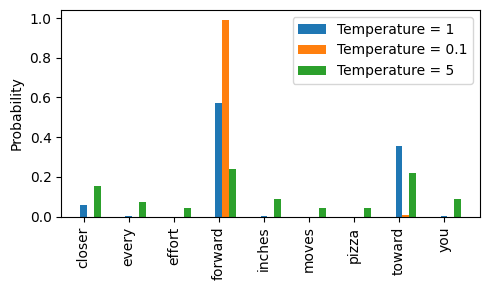

In [40]:
import matplotlib.pyplot as plt

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
  rects = ax.bar(x+i*bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [41]:
tok_k = 3
top_logits, top_pos = torch.topk(next_token_logits, tok_k)
print(top_logits)
print(top_pos)

tensor([6.7500, 6.2800, 4.5100])
tensor([3, 7, 0])


In [42]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [43]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [44]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
       logits = model(idx_cond)
    logits = logits[:, -1, :]

    if top_k is not None:
      top_logits, top_pos = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

    if temperature > 0:
      logits = logits / temperature

      probs = torch.softmax(logits, dim=-1)

      idx_next = torch.multinomial(probs, num_samples=1)

    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if idx_next == eos_id:
      break

    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [45]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=generate_text_to_token("Computer Virus injected", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k = 25,
    temperature=1.4
)
print(generate_token_to_text(token_ids, tokenizer))

Computer Virus injected ponies wearing Study................................ nightmares 180 Ambassador cueIndust Hispan Marinoscrib 1980 Sil 1933


In [47]:
model = DummyGPTModel(GPT_CONFIG_124M)
torch.save(model.state_dict(), "model.pth")

In [48]:
model.load_state_dict(torch.load("model.pth"))
model.eval()

DummyGPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_block): Sequential(
    (0): DummyTransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): DummyLayerNorm()
      (norm2): DummyLayerNorm()
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): DummyTransformerBlock(
      (att): MultiHeadAttention(
       

In [49]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [50]:
checkpoint = torch.load("model_and_optimizer.pth")
model = DummyGPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();